In [1]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# TESTING_FOLDER = Path.home() / Path("Desktop/testing")
TESTING_FOLDER = Path("testing/")
METADATA_PATH = TESTING_FOLDER / "metadata.xlsx"

In [3]:
df = pd.read_excel(METADATA_PATH)
id_map = {row.Path: i for i, row in enumerate(df.itertuples(index=False))}
df["id"] = df["Path"].map(id_map)
df

,Path,Description,id
0,1.jpg,Screenshot of a meme showing an orange cat cov...,0
1,2.jpg,A photograph of a dog curled up lying on its d...,1
2,3.jpg,An image of a tree-shaped antenna mounted outd...,2
3,4.jpg,A meme image featuring a cat with wide terrifi...,3
4,5.jpg,A cartoon drawing of a dog with a thought bubb...,4
5,6.jpg,A two-panel comic strip showing a woman saying...,5
6,7.jpg,An image of a masked man wearing a t-shirt wit...,6
7,8.jpg,A screenshot of a tweet containing a line grap...,7
8,9.jpg,"The classic ""are you winning, son?"" meme showi...",8
9,10.jpg,A social media post about computer safety or c...,9


In [4]:
TOP_K = 4

In [5]:
def reciprocal_rank(results, correct_id):
    try:
        rank = results.index(correct_id) + 1
        return 1 / rank
    except ValueError:
        return 0.0
    
def hit_at_k(results, correct_id, k):
    return int(correct_id in results[:k])

In [6]:
from cli.platform_file_revealer import PlatformFileRevealer
from cli.table_maker import TableMaker
from infrastructure.services.multimedia_type_detector import MultimediaTypeFinder
from infrastructure.bge_small_encoder import BGEEncoder
from infrastructure.qdrant.qdrant_vdb import QdrantVectorDatabase
from infrastructure.qdrant.qdrant_output_processor import QdrantOutputProcessor
from infrastructure.ml.device import get_device_config
from cli.cli_decoder import CLIDecoder
from settings import *

from dotenv import load_dotenv
import os


load_dotenv("config.env")
hf_token = os.getenv("HF_TOKEN")
config = get_device_config()

encoder = BGEEncoder(hf_token, config)
db = QdrantVectorDatabase()
mtf = MultimediaTypeFinder()

output_processor = QdrantOutputProcessor()
table_maker = TableMaker()
revealer = PlatformFileRevealer()

/Users/williamleonheart/Documents/multimedia-by-prompt-search/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1946.44it/s]


In [7]:
N = len(df)

hit_matrices = {
    k: pd.DataFrame(
        0,
        index=range(N),
        columns=range(N),
        dtype=int
    )
    for k in range(1, TOP_K + 1)
}

In [8]:
for row in df.itertuples(index=False):
    target_id = row.id
    query_text = row.Description
    real_path = row.Path

    embedding = encoder.encode(query_text)
    results = db.search(embedding, TOP_K)

    rows = output_processor.create_dict_of_rows(results)

    print("\n" + "=" * 120)
    print(f"QUERY (real description): {query_text}")
    print(f"GROUND TRUTH PATH: {real_path}")
    print(f"GROUND TRUTH ID: {target_id}")

    print("\nTOP RESULTS:")

    retrieved_ids = []

    for rank, r in enumerate(rows):
        path = r.get("path")
        db_desc = r.get("text_description", None)
        score = r.get("score", None)

        file_id = id_map.get(Path(path).name) if path else None
        retrieved_ids.append(file_id)

        print(f"\nRank {rank + 1}")
        print(f"Path: {path}")
        print(f"DB Description: {db_desc}")
        print(f"Score: {score}")
        print(f"Mapped ID: {file_id}")

        for k in range(1, TOP_K + 1):
            if target_id in retrieved_ids[:k]:
                hit_matrices[k].loc[target_id, target_id] = 1

    hit1 = hit_at_k(retrieved_ids, target_id, 1)
    print(f"\nHIT@1: {hit1}")


QUERY (real description): Screenshot of a meme showing an orange cat covering its face with one paw. An emoji below the cat mimics the same embarrassed facial expression.
GROUND TRUTH PATH: 1.jpg
GROUND TRUTH ID: 0

TOP RESULTS:

Rank 1
Path: testing/vid_20.mp4
DB Description: This image appears to be a screenshot from a video, likely designed in a simplistic and stylized graphic medium, given the bold lines and flat areas of color. The primary subject is a cat positioned in an outdoor setting, which seems to be a garden area, as suggested by the presence of greenery and a brick wall
Score: 0.7551908428073888
Mapped ID: 39

Rank 2
Path: testing/4.jpg
DB Description: This image captures a close-up view of a cat that has been dramatically altered to convey an exaggerated expression of shock or surprise. The photo appears to have been manipulated, likely through Photoshop, which has positioned the cat's head in the center of the frame. The cat's face possesses a tan color with gray fur, 

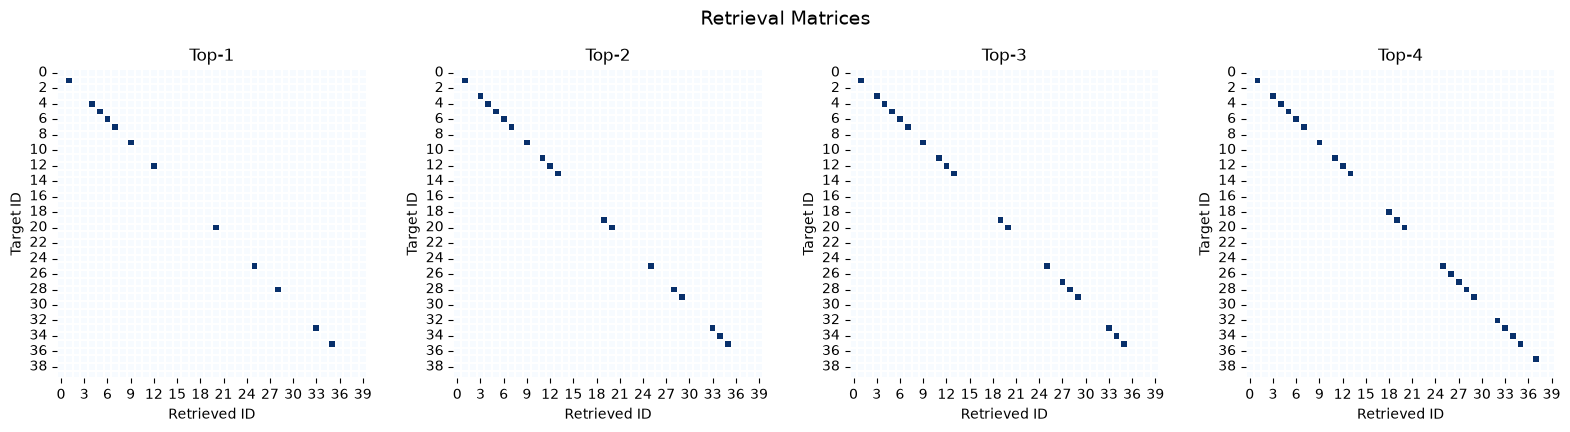

In [9]:
import math

fig_cols = TOP_K
fig_rows = math.ceil(len(hit_matrices) / fig_cols)

fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(fig_cols * 4, fig_rows * 4))
axes = axes.flatten()

for idx, (k, matrix) in enumerate(hit_matrices.items()):
    sns.heatmap(
        matrix,
        ax=axes[idx],
        cmap="Blues",
        square=True,
        cbar=False,
        linewidths=0.2,
    )
    axes[idx].set_title(f"Top-{k}")
    axes[idx].set_xlabel("Retrieved ID")
    axes[idx].set_ylabel("Target ID")

for idx in range(len(hit_matrices), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Retrieval Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
len(df)

40

In [11]:
db.client.close()